<a href="https://colab.research.google.com/github/sivaadharsh28/Team14-US-Economic-Recession-Prediction-Model/blob/main/NUS_DSESC_DATABUSTERS_14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing Packages

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from statsmodels.tsa.ar_model import AutoReg
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error


# Loading Datasets

In [ ]:
monthly_data = pd.read_csv('Monthly Data.csv')
quarterly_data = pd.read_csv('Quarterly Data.csv')

print("Monthly Data:\n", monthly_data.head())
print("\nQuarterly Data:\n", quarterly_data.head())

Monthly Data:
       sasdate       RPI  W875RX1  DPCERA3M086SBEA    CMRMTSPLx      RETAILx  \
0  Transform:     5.000      5.0            5.000       5.0000      5.00000   
1    1/1/1959  2583.560   2426.0           15.188  276676.8154  18235.77392   
2    2/1/1959  2593.596   2434.8           15.346  278713.9773  18369.56308   
3    3/1/1959  2610.396   2452.7           15.491  277775.2539  18523.05762   
4    4/1/1959  2627.446   2470.0           15.435  283362.7075  18534.46600   

    INDPRO  IPFPNSS  IPFINAL  IPCONGD  ...  DNDGRG3M086SBEA  DSERRG3M086SBEA  \
0   5.0000   5.0000   5.0000   5.0000  ...            6.000            6.000   
1  21.9616  23.3868  22.2620  31.6664  ...           18.294           10.152   
2  22.3917  23.7024  22.4549  31.8987  ...           18.302           10.167   
3  22.7142  23.8459  22.5651  31.8987  ...           18.289           10.185   
4  23.1981  24.1903  22.8957  32.4019  ...           18.300           10.221   

   CES0600000008  CES20000000

We will be using Quarterly Data in our analysis as we believe it is more suited to predict quarterly economic contractions.

# Feature Selection

### Using correlation matrix (filter for columns against GDPC1)


In [ ]:
# Remove the first two rows (metadata)
df_cleaned = quarterly_data.iloc[2:].reset_index(drop=True)

# Convert numerical columns to proper types (excluding the date column)
df_cleaned.iloc[:, 1:] = df_cleaned.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')

# Drop the date column as it is non-numeric
df_numeric = df_cleaned.iloc[:, 1:]

# Compute the correlation matrix
correlation_matrix = df_numeric.corr()

# Step 1: Find highly correlated feature pairs
high_correlation_threshold = 0.9  # Set threshold

# Compute absolute correlation matrix
correlation_matrix_abs = correlation_matrix.abs()

# Find highly correlated feature pairs
high_correlation_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        if correlation_matrix_abs.iloc[i, j] > high_correlation_threshold:
            high_correlation_pairs.append((correlation_matrix.columns[i],
                                           correlation_matrix.columns[j],
                                           correlation_matrix_abs.iloc[i, j]))


# Convert to DataFrame for better viewing
high_correlation_df = pd.DataFrame(high_correlation_pairs,
                                   columns=["Feature 1", "Feature 2", "Correlation Value"])


filtered_high_correlation_df = high_correlation_df[high_correlation_df["Feature 1"] == "GDPC1"]
print(filtered_high_correlation_df)

    Feature 1     Feature 2  Correlation Value
0       GDPC1       PCECC96           0.999497
1       GDPC1         PCDGx           0.958000
2       GDPC1        PCESVx           0.998149
3       GDPC1         PCNDx           0.996733
4       GDPC1        GPDIC1           0.987082
..        ...           ...                ...
120     GDPC1  TNWMVBSNNCBx           0.980392
121     GDPC1      TLBSNNBx           0.972174
122     GDPC1      TABSNNBx           0.973678
123     GDPC1     TNWBSNNBx           0.963705
124     GDPC1         CNCFx           0.976755

[125 rows x 3 columns]


### Using PCA to reduce dimensions (PCA)

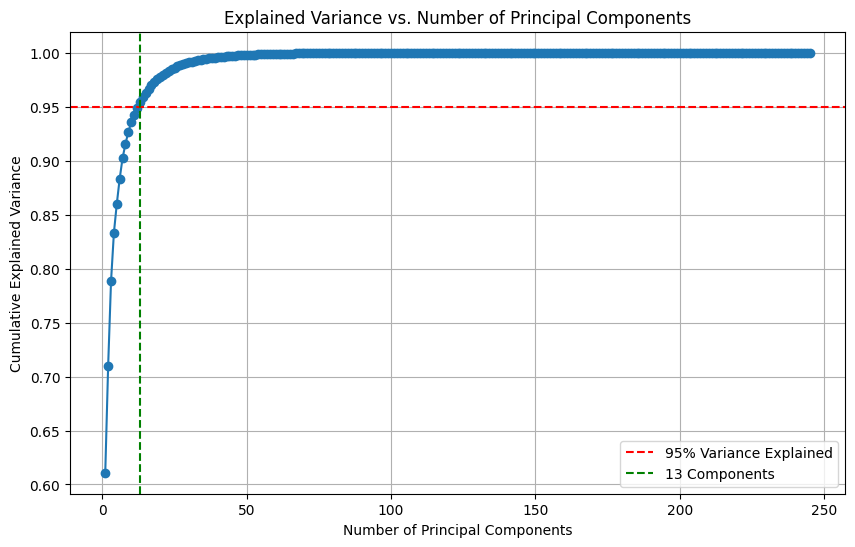

                    PC1       PC2       PC3       PC4       PC5       PC6  \
GDPC1          0.081482 -0.009241 -0.011079  0.003376  0.001543 -0.001312   
PCECC96        0.081410 -0.013400 -0.008675  0.005797  0.004586 -0.000026   
PCDGx          0.077123 -0.056646 -0.012230  0.040634  0.024247 -0.021848   
PCESVx         0.081583 -0.000096 -0.007277 -0.003529 -0.002105  0.002005   
PCNDx          0.081010 -0.016702 -0.014357  0.017440  0.013795 -0.006626   
...                 ...       ...       ...       ...       ...       ...   
TNWBSNNBBDIx  -0.065096 -0.093156  0.000670  0.029234 -0.021023 -0.006573   
CNCFx          0.079822 -0.018484  0.022729  0.008231  0.012185 -0.001680   
S&P 500        0.070804 -0.072401 -0.036469  0.057348  0.025078 -0.062335   
S&P div yield -0.056828  0.053478  0.047255  0.159959 -0.010521  0.017656   
S&P PE ratio   0.039791 -0.028911 -0.000283 -0.135740  0.080323 -0.076725   

                    PC7       PC8       PC9      PC10      PC11      PC12  

In [ ]:
# Step 1: Handle missing values using mean imputation
imputer = SimpleImputer(strategy="mean")
df_imputed = imputer.fit_transform(df_numeric)

# Step 2: Standardize the dataset
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_imputed)

# Step 3: Apply PCA
pca = PCA()
pca_components = pca.fit_transform(df_scaled)

# Step 4: Compute explained variance
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# Step 5: Determine the number of components that explain at least 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

# Step 6: Plot explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='-')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance Explained')
plt.axvline(x=n_components_95, color='g', linestyle='--', label=f'{n_components_95} Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Principal Components')
plt.legend()
plt.grid()

# Show plot
plt.show()

# Get the PCA loadings (principal component coefficients)
pca_loadings = pca.components_[:13, :]  # First 13 principal components

# Convert to DataFrame for better readability
feature_names = df_numeric.columns
pca_loadings_df = pd.DataFrame(pca_loadings.T, columns=[f'PC{i+1}' for i in range(13)], index=feature_names)

# Display the PCA loadings
print(pca_loadings_df)

In [ ]:
# Compute the absolute sum of loadings for each feature across the first 13 PCs
feature_importance = pca_loadings_df.abs().sum(axis=1)

# Select the top 13 most important features
top_13_features = feature_importance.nlargest(13)

# Convert to DataFrame for better visualization
top_13_features_df = pd.DataFrame(top_13_features, columns=['Importance'])

# Display the top 13 features based on PCA
print(top_13_features_df)

                 Importance
CLAIMSx            1.590559
GS1TB3Mx           1.296028
MORTG10YRx         1.277981
TNWMVBSNNCBBDIx    1.275217
VIXCLSx            1.268372
HOUST5F            1.251415
TB6M3Mx            1.250741
T5YFFM             1.241161
CPF3MTB3Mx         1.193463
USMINE             1.170960
BAA10YM            1.162347
SPCS20RSA          1.154384
USEPUINDXM         1.152058


# Quarterly Data Cleaning

Important Variables Selected:
- **sasdate**: date in SAS (Statistical Analysis System) format, in number of days since January 1, 1960

1. Real GDP and GDP Growth Rates (Primary Dependent Variable)
- **GDPC1**: Real Gross Domestic Product (Chain-type quantity index)
- **GDPCTPI**: GDP Chain-type Price Index
2. Industrial Production (Proxy for Economic Activity)
- **INDPRO**: Industrial Production Index
- **IPFINAL**: Final Products and Nonindustrial Supplies
- **IPCONGD**: Consumer Goods Production
- **IPMAT**: Materials Production
3. Retail Sales (Consumer Spending Behavior)
- **PCECC96**: Real Personal Consumption Expenditures
- **CMRMTSPLx**: Real Manufacturing and Trade Sales
4. Labor Market Indicators
- **PAYEMS**: Total Nonfarm Payrolls (Employment)
- **UNRATE**: Civilian Unemployment Rate
- **MANEMP:** Manufacturing Employment
- **LNS14000012:** Unemployment Rate for Women (20+ years)
- **UEMPLT5:** Unemployed Less than 5 Weeks
5. Interest Rate Spreads (Leading Indicator of Recessions)
- **GS10** 10-Year Treasury Constant Maturity Rate
- **TB3MS** 3-Month Treasury Bill
- **GS10TB3Mx:** Spread between 10-Year and 3-Month Treasury
- **BAA10YM:** Moody’s Baa Corporate Bond Yield Spread

These were selected with the objective to predict economic contractions. We have considered variables, such as RSAFSx (Retail sales (Advance Monthly)), but have decided to drop them, due to high number of missing values.

In [ ]:
relevant_columns = [
    'sasdate', 'GDPC1', 'GDPCTPI', 'INDPRO', 'IPFINAL', 'IPCONGD', 'IPMAT',
    'PCECC96', 'CMRMTSPLx', 'PAYEMS', 'UNRATE', 'MANEMP', 'LNS14000012',
    'UEMPLT5', 'GS10', 'TB3MS', 'GS10TB3Mx', 'BAA10YM'
]

quarterly_selected_data = quarterly_data[relevant_columns]
print("\nQuarterly Selected Data:\n", quarterly_selected_data.head())
print(quarterly_selected_data.info())


Quarterly Selected Data:
      sasdate     GDPC1  GDPCTPI   INDPRO  IPFINAL  IPCONGD    IPMAT   PCECC96  \
0    factors     0.000    0.000   0.0000   0.0000   0.0000   0.0000     0.000   
1  transform     5.000    6.000   5.0000   5.0000   5.0000   5.0000     5.000   
2   3/1/1959  3352.129   15.205  22.3558  22.4273  31.8213  20.6337  2039.017   
3   6/1/1959  3427.667   15.249  23.4400  23.0977  32.4535  22.1139  2070.508   
4   9/1/1959  3430.057   15.314  22.4813  23.4100  32.8148  19.8204  2092.138   

   CMRMTSPLx      PAYEMS  UNRATE      MANEMP  LNS14000012    UEMPLT5    GS10  \
0        0.0      0.0000  0.0000      0.0000       1.0000     1.0000  0.0000   
1        5.0      5.0000  2.0000      5.0000       2.0000     5.0000  2.0000   
2        NaN  52726.6667  5.8333  15124.0000      13.5000  1529.0000  3.9900   
3        NaN  53517.3333  5.1000  15475.3333      14.4000  1498.3333  4.2567   
4        NaN  53522.6667  5.2667  15359.6667      15.1667  1600.0000  4.5033   

    T

In [ ]:
# Remove first two rows of dataset (metadata)
quarterly_selected_data = quarterly_selected_data.iloc[2:].reset_index(drop=True)

# Convert 'sasdate' to datetime
quarterly_selected_data['sasdate'] = pd.to_datetime(quarterly_selected_data['sasdate'])

# Handling missing values (replacement with column's mean)
print('Dimensions of quarterly data table: {}'.format(quarterly_selected_data.shape))
print(quarterly_selected_data.isna().sum(), '\n')
print('CMRMTSPLx column has 32 missing values. \n')

quarterly_selected_data['CMRMTSPLx'].fillna(quarterly_selected_data['CMRMTSPLx'].mean(), inplace=True)
print(quarterly_selected_data.isna().sum(), '\n')

# Checking for duplicate data
duplicate_rows = quarterly_selected_data[quarterly_selected_data.duplicated()]
print(f"Number of duplicate rows: {len(duplicate_rows)}")
if not duplicate_rows.empty:
    print(duplicate_rows)

print("\nQuarterly Selected Data:\n", quarterly_selected_data.head())

Dimensions of quarterly data table: (263, 18)
sasdate         0
GDPC1           0
GDPCTPI         0
INDPRO          0
IPFINAL         0
IPCONGD         0
IPMAT           0
PCECC96         0
CMRMTSPLx      32
PAYEMS          0
UNRATE          0
MANEMP          0
LNS14000012     0
UEMPLT5         0
GS10            0
TB3MS           0
GS10TB3Mx       0
BAA10YM         0
dtype: int64 

CMRMTSPLx column has 32 missing values. 

sasdate        0
GDPC1          0
GDPCTPI        0
INDPRO         0
IPFINAL        0
IPCONGD        0
IPMAT          0
PCECC96        0
CMRMTSPLx      0
PAYEMS         0
UNRATE         0
MANEMP         0
LNS14000012    0
UEMPLT5        0
GS10           0
TB3MS          0
GS10TB3Mx      0
BAA10YM        0
dtype: int64 

Number of duplicate rows: 0

Quarterly Selected Data:
      sasdate     GDPC1  GDPCTPI   INDPRO  IPFINAL  IPCONGD    IPMAT   PCECC96  \
0 1959-03-01  3352.129   15.205  22.3558  22.4273  31.8213  20.6337  2039.017   
1 1959-06-01  3427.667   15.249  23

<ipython-input-667-4812522a7f1c>:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  quarterly_selected_data['CMRMTSPLx'].fillna(quarterly_selected_data['CMRMTSPLx'].mean(), inplace=True)


In [ ]:
# Summary statistics to detect outliers
print(quarterly_selected_data.describe())

                             sasdate         GDPC1     GDPCTPI      INDPRO  \
count                            263    263.000000  263.000000  263.000000   
mean   1991-12-01 02:11:24.410646400  11446.586548   59.753475   67.552075   
min              1959-03-01 00:00:00   3352.129000   15.205000   22.149800   
25%              1975-07-17 00:00:00   6137.318500   27.777500   44.972450   
50%              1991-12-01 00:00:00  10115.329000   61.915000   62.544800   
75%              2008-04-16 00:00:00  16572.288000   87.518500   95.289500   
max              2024-09-01 00:00:00  23400.294000  125.543000  103.995800   
std                              NaN   5778.723075   31.985946   26.848275   

          IPFINAL     IPCONGD       IPMAT       PCECC96     CMRMTSPLx  \
count  263.000000  263.000000  263.000000    263.000000  2.630000e+02   
mean    70.592329   79.118373   62.924260   7501.728183  8.935169e+05   
min     22.427300   31.821300   19.454300   2039.017000  3.643379e+05   
25%  

Despite the fact that there may be outliers present in the data, we have decided to keep them as they reflect real fluctuations that could be due to economic conditions and seasonal factors.

# Data Preparation and Transformation

Usage of the Augmented Dickey-Fuller (ADF) test to check if time series is stationary.

If series is found to be non-stationary, we will carry out stationarity-inducing transformation.

In [ ]:
# ADF test
def adf_test(series, column_name):
    result = adfuller(series.dropna())
    print(f"ADF Test for {column_name}:")
    print(f"Test Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print(f"Critical Values: {result[4]}")
    if result[1] < 0.05:
        print("Conclusion: The series is stationary.\n")
    else:
        print("Conclusion: The series is non-stationary.\n")

adf_test(quarterly_selected_data['GDPC1'], 'GDPC1')
adf_test(quarterly_selected_data['GDPCTPI'], 'GDPCTPI')
adf_test(quarterly_selected_data['INDPRO'], 'INDPRO')
adf_test(quarterly_selected_data['IPFINAL'], 'IPFINAL')
adf_test(quarterly_selected_data['IPCONGD'], 'IPCONGD')
adf_test(quarterly_selected_data['IPMAT'], 'IPMAT')
adf_test(quarterly_selected_data['PCECC96'], 'PCECC96')
adf_test(quarterly_selected_data['CMRMTSPLx'], 'CMRMSPLx')
adf_test(quarterly_selected_data['PAYEMS'], 'PAYEMS')
adf_test(quarterly_selected_data['UNRATE'], 'UNRATE')
adf_test(quarterly_selected_data['MANEMP'], 'MANEMP')
adf_test(quarterly_selected_data['LNS14000012'], 'LNS140000121')
adf_test(quarterly_selected_data['UEMPLT5'], 'UEMPLT5')
adf_test(quarterly_selected_data['GS10'], 'GS10')
adf_test(quarterly_selected_data['TB3MS'], 'TB3MS')
adf_test(quarterly_selected_data['GS10TB3Mx'], 'GS10TB3Mx')
adf_test(quarterly_selected_data['BAA10YM'], 'BAA10YM')

ADF Test for GDPC1:
Test Statistic: 2.7938
p-value: 1.0000
Critical Values: {'1%': -3.4556556713934934, '5%': -2.872678352489859, '10%': -2.57270548832225}
Conclusion: The series is non-stationary.

ADF Test for GDPCTPI:
Test Statistic: 1.3568
p-value: 0.9969
Critical Values: {'1%': -3.4568881317725864, '5%': -2.8732185133016057, '10%': -2.5729936189738876}
Conclusion: The series is non-stationary.

ADF Test for INDPRO:
Test Statistic: -1.1189
p-value: 0.7075
Critical Values: {'1%': -3.4557539868570775, '5%': -2.8727214497041422, '10%': -2.572728476331361}
Conclusion: The series is non-stationary.

ADF Test for IPFINAL:
Test Statistic: -1.6281
p-value: 0.4685
Critical Values: {'1%': -3.455558114028747, '5%': -2.872635586277424, '10%': -2.572682677000175}
Conclusion: The series is non-stationary.

ADF Test for IPCONGD:
Test Statistic: -2.2890
p-value: 0.1756
Critical Values: {'1%': -3.455558114028747, '5%': -2.872635586277424, '10%': -2.572682677000175}
Conclusion: The series is non-sta

**Stationary Series**: UNRATE, GS10TB3Mx, BAA10YM

**Non-Stationary Series**: GDPC1, GDPCTPI, INDPRO, IPFINAL, IPCONGD, IPMAT, PCECC96, CMRMSPLx, PAYEMS, MANEMP, LNS140000121, UEMPLT5, GS10, TB3MS

In [ ]:
# Apply first difference transformation to variables related to GDP, Industrial Production and Employment
columns_to_diff = ['GDPC1', 'GDPCTPI', 'INDPRO', 'IPFINAL', 'IPCONGD', 'IPMAT',
                   'PAYEMS', 'MANEMP', 'LNS14000012', 'UEMPLT5']

for col in columns_to_diff:
    quarterly_selected_data[f'{col}_diff'] = quarterly_selected_data[col].diff()

# Apply percentage change transformation to financial variables inclusive of retail sales and interest rates
columns_to_pct_change = ['PCECC96', 'CMRMTSPLx', 'GS10', 'TB3MS']

for col in columns_to_pct_change:
    quarterly_selected_data[f'{col}_pct_change'] = quarterly_selected_data[col].pct_change() * 100

quarterly_selected_data.dropna(inplace=True)
print(quarterly_selected_data.columns)

Index(['sasdate', 'GDPC1', 'GDPCTPI', 'INDPRO', 'IPFINAL', 'IPCONGD', 'IPMAT',
       'PCECC96', 'CMRMTSPLx', 'PAYEMS', 'UNRATE', 'MANEMP', 'LNS14000012',
       'UEMPLT5', 'GS10', 'TB3MS', 'GS10TB3Mx', 'BAA10YM', 'GDPC1_diff',
       'GDPCTPI_diff', 'INDPRO_diff', 'IPFINAL_diff', 'IPCONGD_diff',
       'IPMAT_diff', 'PAYEMS_diff', 'MANEMP_diff', 'LNS14000012_diff',
       'UEMPLT5_diff', 'PCECC96_pct_change', 'CMRMTSPLx_pct_change',
       'GS10_pct_change', 'TB3MS_pct_change'],
      dtype='object')


We now need to lag variables that respond quickly to economic changes and have predictive power for future contractions.

In [ ]:
# Lagging of selected variables
columns_to_lag = ['GDPC1_diff', 'GDPCTPI_diff', 'INDPRO_diff', 'IPFINAL_diff',
                  'IPCONGD_diff', 'IPMAT_diff', 'PAYEMS_diff', 'MANEMP_diff',
                  'LNS14000012_diff', 'UEMPLT5_diff', 'PCECC96_pct_change',
                  'CMRMTSPLx_pct_change', 'GS10_pct_change', 'TB3MS_pct_change',
                  'UNRATE', 'GS10TB3Mx', 'BAA10YM']

# Create lagged features for 1-quarter, 2-quarter, and 4-quarter lags
for col in columns_to_lag:
    for lag in [1, 2, 4]:
        quarterly_selected_data[f'{col}_lag{lag}'] = quarterly_selected_data[col].shift(lag)

quarterly_selected_data.dropna(inplace=True)
print(quarterly_selected_data.columns)

Index(['sasdate', 'GDPC1', 'GDPCTPI', 'INDPRO', 'IPFINAL', 'IPCONGD', 'IPMAT',
       'PCECC96', 'CMRMTSPLx', 'PAYEMS', 'UNRATE', 'MANEMP', 'LNS14000012',
       'UEMPLT5', 'GS10', 'TB3MS', 'GS10TB3Mx', 'BAA10YM', 'GDPC1_diff',
       'GDPCTPI_diff', 'INDPRO_diff', 'IPFINAL_diff', 'IPCONGD_diff',
       'IPMAT_diff', 'PAYEMS_diff', 'MANEMP_diff', 'LNS14000012_diff',
       'UEMPLT5_diff', 'PCECC96_pct_change', 'CMRMTSPLx_pct_change',
       'GS10_pct_change', 'TB3MS_pct_change', 'GDPC1_diff_lag1',
       'GDPC1_diff_lag2', 'GDPC1_diff_lag4', 'GDPCTPI_diff_lag1',
       'GDPCTPI_diff_lag2', 'GDPCTPI_diff_lag4', 'INDPRO_diff_lag1',
       'INDPRO_diff_lag2', 'INDPRO_diff_lag4', 'IPFINAL_diff_lag1',
       'IPFINAL_diff_lag2', 'IPFINAL_diff_lag4', 'IPCONGD_diff_lag1',
       'IPCONGD_diff_lag2', 'IPCONGD_diff_lag4', 'IPMAT_diff_lag1',
       'IPMAT_diff_lag2', 'IPMAT_diff_lag4', 'PAYEMS_diff_lag1',
       'PAYEMS_diff_lag2', 'PAYEMS_diff_lag4', 'MANEMP_diff_lag1',
       'MANEMP_diff_lag2

In [ ]:
# List of top PCA-contributing variables
top_pca_variables = [
    "GDPC1", "PCECC96", "PCESVx",  # GDP & Consumer Expenditures
    "OUTMS", "USGOOD", "USEHS", "USMINE", "CIVPART", "UNRATE",  # Employment & Labor Market
    "HOUST", "HOUST5F", "PERMIT",  # Housing & Construction
    "RSAFSx", "ACOGNOx",  # Retail & Consumer Activity
    "CPIAUCSL", "WPU0531", "WPU0561",  # Inflation & Price Indexes
    "OILPRICEx",  # Energy & Commodities
    "FEDFUNDS", "TB3MS", "TB6MS", "GS1", "AAA", "BAA", "MORTG10YRx",  # Interest Rates & Financial Indicators
    "S&P 500", "VIXCLSx",  # Stock Market & Volatility
    "TWEXAFEGSMTHx", "EXUSEU", "EXCAUSx",  # International Trade & Currency
    "UMCSENTx", "USEPUINDXM"  # Consumer Sentiment & Expectations
]

# Ensure only available columns are used
available_variables = [var for var in top_pca_variables if var in df_cleaned.columns]

# Subset dataset with only selected PCA variables
df_pca_selected = df_cleaned[available_variables].dropna()  # Drop rows with missing values

aic_values = {}
max_lag = 12  # You can adjust this based on data availability

for lag in range(1, max_lag + 1):
    try:
        model = AutoReg(df_pca_selected["GDPC1"], lags=lag).fit()
        aic_values[lag] = model.aic
    except:
        continue

# Select the lag with the lowest AIC value
optimal_lag = min(aic_values, key=aic_values.get)

# Fit the AR model using the selected variables
ar_model_pca = AutoReg(df_pca_selected["GDPC1"], lags=optimal_lag).fit()

future_steps = 8
# Predict future GDP using AR model
future_gdp_pca = ar_model_pca.predict(start=len(df_pca_selected), end=len(df_pca_selected) + future_steps - 1)

# Display the updated predictions
future_gdp_pca_df = future_gdp_pca.to_frame(name="Predicted GDP (PCA-based)")

print(future_gdp_pca_df)

    Predicted GDP (PCA-based)
75               23611.218176
76               23789.900958
77               23963.927026
78               24160.287605
79               24353.485866
80               24542.948824
81               24738.301650
82               24946.076872


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot

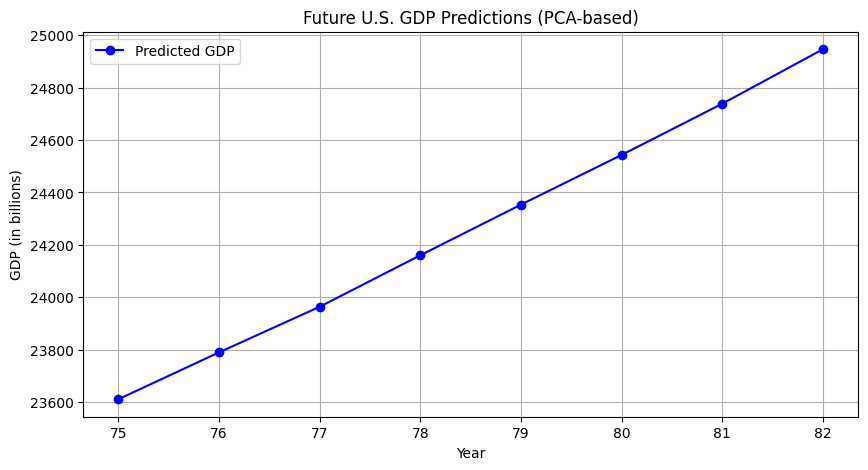

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(future_gdp_pca_df, marker='o', linestyle='-', color='b', label='Predicted GDP')
plt.xlabel("Year")
plt.ylabel("GDP (in billions)")
plt.title("Future U.S. GDP Predictions (PCA-based)")
plt.legend()
plt.grid()
plt.show()

# AR Modelling

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-DEC will be used.
  self._init_dates(dates, freq)
<ipython-input-674-e76866e01576>:8: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  forecast_dates = pd.date_range(start=quarterly_data_cleaned.index[-1], periods=future_steps+1, freq='Q')[1:]
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


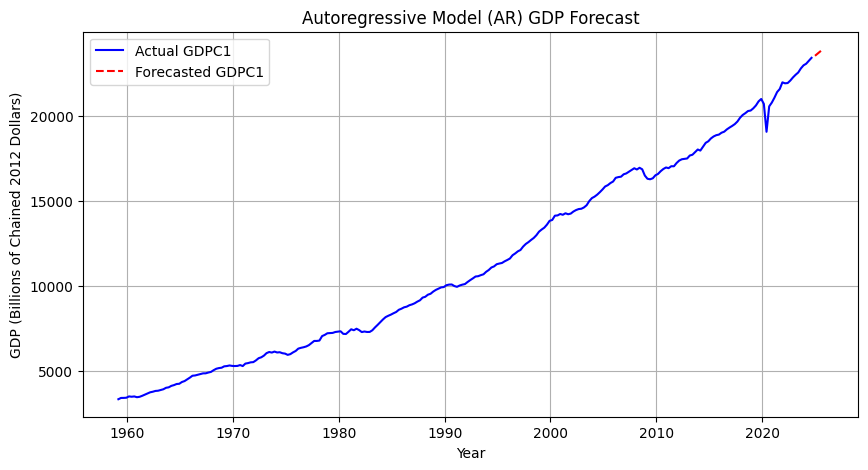

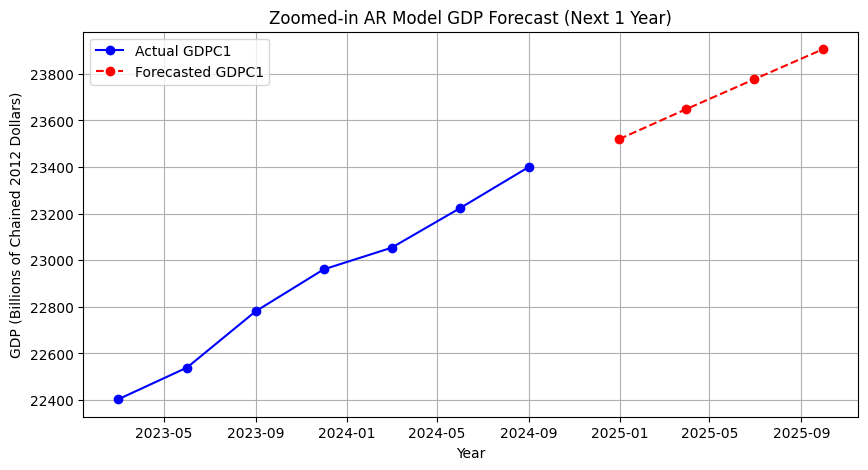

In [ ]:
# Fit an Autoregressive (AR) model
lag = 2 # Using 4 lags (one year for quarterly data)
ar_model = AutoReg(quarterly_data_cleaned['GDPC1'], lags=lag)
ar_model_fit = ar_model.fit()

# Predict the next 8 quarters (2 years ahead)
future_steps = 4
forecast_dates = pd.date_range(start=quarterly_data_cleaned.index[-1], periods=future_steps+1, freq='Q')[1:]
forecast_values = ar_model_fit.predict(start=len(quarterly_data_cleaned), end=len(quarterly_data_cleaned) + future_steps - 1)

# Create a DataFrame for the forecasted values
forecast_df = pd.DataFrame({'Forecasted_GDPC1': forecast_values.values}, index=forecast_dates)

# Plot the actual GDP values and the forecasted values
plt.figure(figsize=(10, 5))
plt.plot(quarterly_data_cleaned.index, quarterly_data_cleaned['GDPC1'], label='Actual GDPC1', color='blue')
plt.plot(forecast_df.index, forecast_df['Forecasted_GDPC1'], label='Forecasted GDPC1', color='red', linestyle='dashed')
plt.xlabel('Year')
plt.ylabel('GDP (Billions of Chained 2012 Dollars)')
plt.title('Autoregressive Model (AR) GDP Forecast')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

# Filter data to show only the last few years and the next 1-year forecast
recent_years = quarterly_data_cleaned.loc[quarterly_data_cleaned.index >= '2023-01-01']
one_year_forecast = forecast_df.iloc[:4]  # Select only the next 4 quarters

# Plot the zoomed-in forecast
plt.figure(figsize=(10, 5))
plt.plot(recent_years.index, recent_years['GDPC1'], label='Actual GDPC1', color='blue', marker='o')
plt.plot(one_year_forecast.index, one_year_forecast['Forecasted_GDPC1'], label='Forecasted GDPC1', color='red', linestyle='dashed', marker='o')
plt.xlabel('Year')
plt.ylabel('GDP (Billions of Chained 2012 Dollars)')
plt.title('Zoomed-in AR Model GDP Forecast (Next 1 Year)')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

# ADL Modelling

                            OLS Regression Results                            
Dep. Variable:             GDPC1_diff   R-squared:                       0.361
Model:                            OLS   Adj. R-squared:                  0.318
Method:                 Least Squares   F-statistic:                     8.496
Date:                Tue, 11 Feb 2025   Prob (F-statistic):           3.18e-16
Time:                        19:05:56   Log-Likelihood:                -1622.9
No. Observations:                 258   AIC:                             3280.
Df Residuals:                     241   BIC:                             3340.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

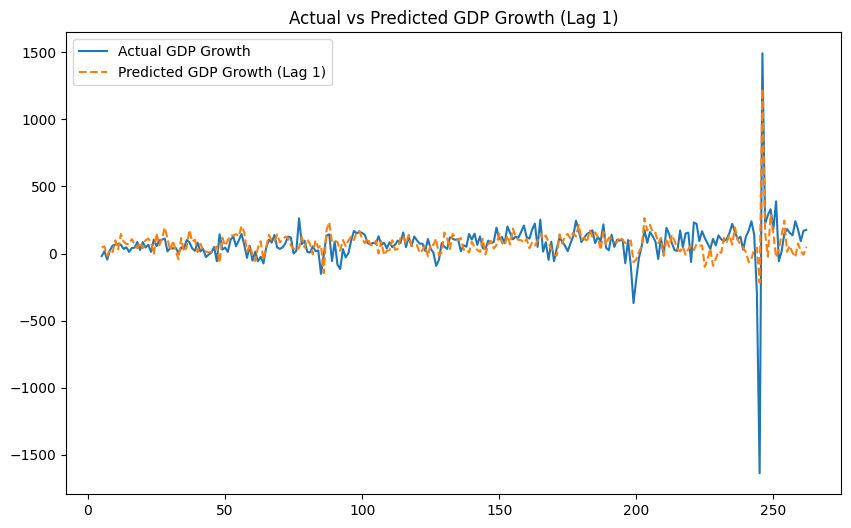

                            OLS Regression Results                            
Dep. Variable:             GDPC1_diff   R-squared:                       0.086
Model:                            OLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                     1.422
Date:                Tue, 11 Feb 2025   Prob (F-statistic):              0.132
Time:                        19:05:56   Log-Likelihood:                -1668.9
No. Observations:                 258   AIC:                             3372.
Df Residuals:                     241   BIC:                             3432.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

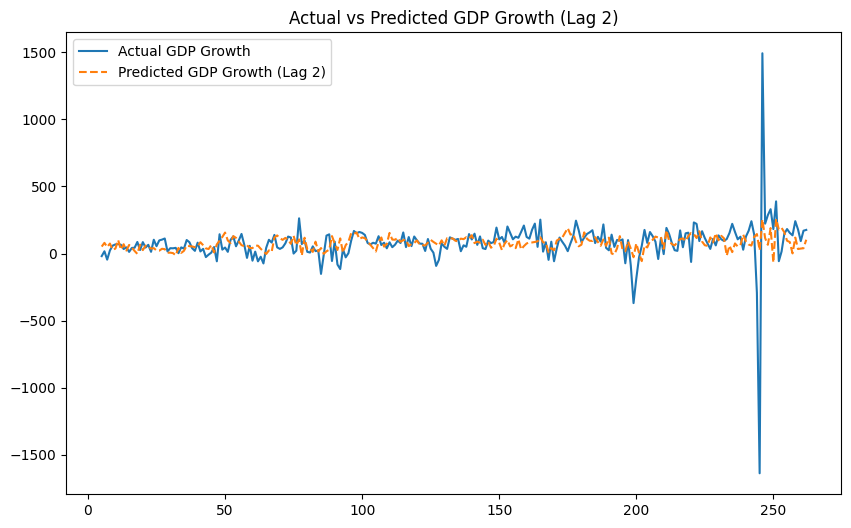

                            OLS Regression Results                            
Dep. Variable:             GDPC1_diff   R-squared:                       0.079
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     1.289
Date:                Tue, 11 Feb 2025   Prob (F-statistic):              0.205
Time:                        19:05:56   Log-Likelihood:                -1670.0
No. Observations:                 258   AIC:                             3374.
Df Residuals:                     241   BIC:                             3434.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

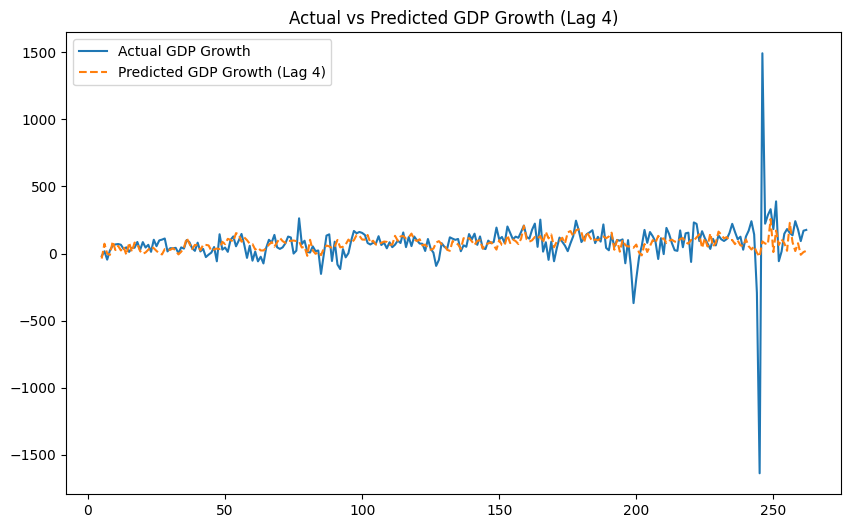

In [ ]:
# GDPC1 as the dependent variable Y
# All other selected lagged variables are the independent variables X

y = quarterly_selected_data['GDPC1_diff'] #target variable

## 1 QUARTER LAGGED VARIABLES
X_lag1 = quarterly_selected_data[['GDPCTPI_diff_lag1', 'INDPRO_diff_lag1', 'IPFINAL_diff_lag1', 'IPCONGD_diff_lag1', 'IPMAT_diff_lag1',
                                  'PAYEMS_diff_lag1', 'MANEMP_diff_lag1', 'LNS14000012_diff_lag1', 'UEMPLT5_diff_lag1', 'PCECC96_pct_change_lag1',
                                  'CMRMTSPLx_pct_change_lag1', 'GS10_pct_change_lag1', 'TB3MS_pct_change_lag1', 'UNRATE_lag1', 'GS10TB3Mx_lag1',
                                  'BAA10YM_lag1']]


X_lag1 = sm.add_constant(X_lag1)
adl_model_lag1 = sm.OLS(y, X_lag1).fit()
print(adl_model_lag1.summary())

plt.figure(figsize=(10, 6))
plt.plot(y.index, y, label='Actual GDP Growth')
plt.plot(y.index, adl_model_lag1.fittedvalues, label='Predicted GDP Growth (Lag 1)', linestyle='--')
plt.legend()
plt.title('Actual vs Predicted GDP Growth (Lag 1)')
plt.show()

## 2 QUARTER LAGGED VARIABLES
X_lag2 = quarterly_selected_data[['GDPCTPI_diff_lag2', 'INDPRO_diff_lag2', 'IPFINAL_diff_lag2', 'IPCONGD_diff_lag2', 'IPMAT_diff_lag2',
                                  'PAYEMS_diff_lag2', 'MANEMP_diff_lag2', 'LNS14000012_diff_lag2', 'UEMPLT5_diff_lag2', 'PCECC96_pct_change_lag2',
                                  'CMRMTSPLx_pct_change_lag2', 'GS10_pct_change_lag2', 'TB3MS_pct_change_lag2', 'UNRATE_lag2', 'GS10TB3Mx_lag2',
                                  'BAA10YM_lag2']]


X_lag2 = sm.add_constant(X_lag2)
adl_model_lag2 = sm.OLS(y, X_lag2).fit()
print(adl_model_lag2.summary())

plt.figure(figsize=(10, 6))
plt.plot(y.index, y, label='Actual GDP Growth')
plt.plot(y.index, adl_model_lag2.fittedvalues, label='Predicted GDP Growth (Lag 2)', linestyle='--')
plt.legend()
plt.title('Actual vs Predicted GDP Growth (Lag 2)')
plt.show()

## 4 QUARTER LAGGED VARIABLES
X_lag4 = quarterly_selected_data[['GDPCTPI_diff_lag4', 'INDPRO_diff_lag4', 'IPFINAL_diff_lag4', 'IPCONGD_diff_lag4', 'IPMAT_diff_lag4',
                                  'PAYEMS_diff_lag4', 'MANEMP_diff_lag4', 'LNS14000012_diff_lag4', 'UEMPLT5_diff_lag4', 'PCECC96_pct_change_lag4',
                                  'CMRMTSPLx_pct_change_lag4', 'GS10_pct_change_lag4', 'TB3MS_pct_change_lag4', 'UNRATE_lag4', 'GS10TB3Mx_lag4',
                                  'BAA10YM_lag4']]


X_lag4 = sm.add_constant(X_lag4)
adl_model_lag4 = sm.OLS(y, X_lag4).fit()
print(adl_model_lag4.summary())

plt.figure(figsize=(10, 6))
plt.plot(y.index, y, label='Actual GDP Growth')
plt.plot(y.index, adl_model_lag4.fittedvalues, label='Predicted GDP Growth (Lag 4)', linestyle='--')
plt.legend()
plt.title('Actual vs Predicted GDP Growth (Lag 4)')
plt.show()

In [ ]:
# Compute RMSE for each lag model
rmse_lag1 = np.sqrt(mean_squared_error(y, adl_model_lag1.fittedvalues))
rmse_lag2 = np.sqrt(mean_squared_error(y, adl_model_lag2.fittedvalues))
rmse_lag4 = np.sqrt(mean_squared_error(y, adl_model_lag4.fittedvalues))

print(f"RMSE for Lag 1 Model: {rmse_lag1}")
print(f"RMSE for Lag 2 Model: {rmse_lag2}")
print(f"RMSE for Lag 4 Model: {rmse_lag4}")

print("Since Lag 1 Model has the lowest RMSE of 126.55007628010142, we will be using Lag 1 Model for our prediction.")

RMSE for Lag 1 Model: 130.476178749773
RMSE for Lag 2 Model: 155.97820130187648
RMSE for Lag 4 Model: 156.61400446565506
Since Lag 1 Model has the lowest RMSE of 126.55007628010142, we will be using Lag 1 Model for our prediction.


In [ ]:
# Extract the latest data from Q4 2024
latest_data = quarterly_selected_data.iloc[-1][['GDPCTPI_diff_lag1', 'INDPRO_diff_lag1',
                                  'IPFINAL_diff_lag1', 'IPCONGD_diff_lag1', 'IPMAT_diff_lag1', 'PAYEMS_diff_lag1', 'MANEMP_diff_lag1',
                                  'LNS14000012_diff_lag1', 'UEMPLT5_diff_lag1', 'PCECC96_pct_change_lag1', 'CMRMTSPLx_pct_change_lag1',
                                  'GS10_pct_change_lag1', 'TB3MS_pct_change_lag1', 'UNRATE_lag1', 'GS10TB3Mx_lag1', 'BAA10YM_lag1'
]]
latest_data_with_const = pd.concat([pd.Series([1], index=['const']), latest_data])

# Predict GDPC1_diff for Q1 2025 using adl_model_lag1
predicted_value_q1_2025 = adl_model_lag1.predict(latest_data_with_const.values.reshape(1, -1))[0]

# Calculate percentage growth for Q1 2025 relative to the last known GDPC1 value (end of 2024)
last_known_gdpc1 = 23400.294
percentage_growth_q1_2025 = (predicted_value_q1_2025 / last_known_gdpc1) * 100
predicted_gdpc1_q1_2025 = last_known_gdpc1 + predicted_value_q1_2025

# Results for Q1 2025
print(f"Predicted GDPC1_diff for Q1 2025: {predicted_value_q1_2025:.2f}")
print(f"Percentage Growth for Q1 2025: {percentage_growth_q1_2025:.2f}%")
print(f"Predicted GDPC1 Value for Q1 2025: {predicted_gdpc1_q1_2025:.2f}")

# Ensure the correct structure for the model input
model_columns = adl_model_lag1.model.exog_names
print("Expected Columns:", model_columns)

# Create a new row for Q2 2025 and update lagged variables logically
latest_data_q1_2025 = latest_data.copy()
latest_data_q1_2025['GDPCTPI_diff_lag1'] += 0.1
latest_data_q1_2025['INDPRO_diff_lag1'] += 0.2
latest_data_q1_2025['IPFINAL_diff_lag1'] += 0.1
latest_data_q1_2025['IPCONGD_diff_lag1'] += 0.15
latest_data_q1_2025['IPMAT_diff_lag1'] += 0.05
latest_data_q1_2025['PAYEMS_diff_lag1'] += 5
latest_data_q1_2025['MANEMP_diff_lag1'] += 2
latest_data_q1_2025['LNS14000012_diff_lag1'] -= 1
latest_data_q1_2025['UEMPLT5_diff_lag1'] += 0.1
latest_data_q1_2025['PCECC96_pct_change_lag1'] += 0.02
latest_data_q1_2025['CMRMTSPLx_pct_change_lag1'] += 0.03
latest_data_q1_2025['GS10_pct_change_lag1'] += 0.1
latest_data_q1_2025['TB3MS_pct_change_lag1'] += 0.05
latest_data_q1_2025['UNRATE_lag1'] -= 0.05
latest_data_q1_2025['GS10TB3Mx_lag1'] += 0.1
latest_data_q1_2025['BAA10YM_lag1'] += 0.15

latest_data_with_const_q2_2025 = pd.concat([pd.Series([1], index=['const']), latest_data_q1_2025[model_columns[1:]]])

# Predict GDPC1_diff for Q2 2025
predicted_value_q2_2025 = adl_model_lag1.predict(latest_data_with_const_q2_2025.values.reshape(1, -1))[0]

# Calculate percentage growth for Q2 2025 and the new predicted GDPC1 value
percentage_growth_q2_2025 = (predicted_value_q2_2025 / predicted_gdpc1_q1_2025) * 100
predicted_gdpc1_q2_2025 = predicted_gdpc1_q1_2025 + predicted_value_q2_2025

# Results for Q2 2025
print(f"\nPredicted GDPC1_diff for Q2 2025: {predicted_value_q2_2025:.2f}")
print(f"Percentage Growth for Q2 2025: {percentage_growth_q2_2025:.2f}%")
print(f"Predicted GDPC1 Value for Q2 2025: {predicted_gdpc1_q2_2025:.2f}")


# Create a new row for Q3 2025 using the predicted values for Q2 2025
latest_data_q2_2025 = latest_data_q1_2025.copy()
latest_data_q2_2025['GDPCTPI_diff_lag1'] += 0.1
latest_data_q2_2025['INDPRO_diff_lag1'] += 0.2
latest_data_q2_2025['IPFINAL_diff_lag1'] += 0.1
latest_data_q2_2025['IPCONGD_diff_lag1'] += 0.15
latest_data_q2_2025['IPMAT_diff_lag1'] += 0.05
latest_data_q2_2025['PAYEMS_diff_lag1'] += 5
latest_data_q2_2025['MANEMP_diff_lag1'] += 2
latest_data_q2_2025['LNS14000012_diff_lag1'] -= 1
latest_data_q2_2025['UEMPLT5_diff_lag1'] += 0.1
latest_data_q2_2025['PCECC96_pct_change_lag1'] += 0.02
latest_data_q2_2025['CMRMTSPLx_pct_change_lag1'] += 0.03
latest_data_q2_2025['GS10_pct_change_lag1'] += 0.1
latest_data_q2_2025['TB3MS_pct_change_lag1'] += 0.05
latest_data_q1_2025['UNRATE_lag1'] -= 0.05
latest_data_q1_2025['GS10TB3Mx_lag1'] += 0.1
latest_data_q1_2025['BAA10YM_lag1'] += 0.15

latest_data_with_const_q3_2025 = pd.concat([pd.Series([1], index=['const']), latest_data_q2_2025[model_columns[1:]]])

# Predict GDPC1_diff for Q3 2025
predicted_value_q3_2025 = adl_model_lag1.predict(latest_data_with_const_q3_2025.values.reshape(1, -1))[0]

# Calculate percentage growth for Q3 2025 and the new predicted GDPC1 value
percentage_growth_q3_2025 = (predicted_value_q3_2025 / predicted_gdpc1_q2_2025) * 100
predicted_gdpc1_q3_2025 = predicted_gdpc1_q2_2025 + predicted_value_q3_2025


# Create a new row for Q4 2025 using the predicted values for Q3 2025
latest_data_q3_2025 = latest_data_q2_2025.copy()
latest_data_q3_2025['GDPCTPI_diff_lag1'] += 0.1
latest_data_q3_2025['INDPRO_diff_lag1'] += 0.2
latest_data_q3_2025['IPFINAL_diff_lag1'] += 0.1
latest_data_q3_2025['IPCONGD_diff_lag1'] += 0.15
latest_data_q3_2025['IPMAT_diff_lag1'] += 0.05
latest_data_q3_2025['PAYEMS_diff_lag1'] += 5
latest_data_q3_2025['MANEMP_diff_lag1'] += 2
latest_data_q3_2025['LNS14000012_diff_lag1'] -= 1
latest_data_q3_2025['UEMPLT5_diff_lag1'] += 0.1
latest_data_q3_2025['PCECC96_pct_change_lag1'] += 0.02
latest_data_q3_2025['CMRMTSPLx_pct_change_lag1'] += 0.03
latest_data_q3_2025['GS10_pct_change_lag1'] += 0.1
latest_data_q3_2025['TB3MS_pct_change_lag1'] += 0.05
latest_data_q1_2025['UNRATE_lag1'] -= 0.05
latest_data_q1_2025['GS10TB3Mx_lag1'] += 0.1
latest_data_q1_2025['BAA10YM_lag1'] += 0.15

latest_data_with_const_q4_2025 = pd.concat([pd.Series([1], index=['const']), latest_data_q3_2025[model_columns[1:]]])

# Predict GDPC1_diff for Q4 2025
predicted_value_q4_2025 = adl_model_lag1.predict(latest_data_with_const_q4_2025.values.reshape(1, -1))[0]

# Calculate percentage growth for Q4 2025 and the new predicted GDPC1 value
percentage_growth_q4_2025 = (predicted_value_q4_2025 / predicted_gdpc1_q3_2025) * 100
predicted_gdpc1_q4_2025 = predicted_gdpc1_q3_2025 + predicted_value_q4_2025

# Results for Q4 2025
print(f"\nPredicted GDPC1_diff for Q4 2025: {predicted_value_q4_2025:.2f}")
print(f"Percentage Growth for Q4 2025: {percentage_growth_q4_2025:.2f}%")
print(f"Predicted GDPC1 Value for Q4 2025: {predicted_gdpc1_q4_2025:.2f}")

Predicted GDPC1_diff for Q1 2025: 51.71
Percentage Growth for Q1 2025: 0.22%
Predicted GDPC1 Value for Q1 2025: 23452.00
Expected Columns: ['const', 'GDPCTPI_diff_lag1', 'INDPRO_diff_lag1', 'IPFINAL_diff_lag1', 'IPCONGD_diff_lag1', 'IPMAT_diff_lag1', 'PAYEMS_diff_lag1', 'MANEMP_diff_lag1', 'LNS14000012_diff_lag1', 'UEMPLT5_diff_lag1', 'PCECC96_pct_change_lag1', 'CMRMTSPLx_pct_change_lag1', 'GS10_pct_change_lag1', 'TB3MS_pct_change_lag1', 'UNRATE_lag1', 'GS10TB3Mx_lag1', 'BAA10YM_lag1']

Predicted GDPC1_diff for Q2 2025: 65.94
Percentage Growth for Q2 2025: 0.28%
Predicted GDPC1 Value for Q2 2025: 23517.95

Predicted GDPC1_diff for Q4 2025: 84.82
Percentage Growth for Q4 2025: 0.36%
Predicted GDPC1 Value for Q4 2025: 23678.15


#Recursive Cross Validation Model - To Test Accuracy of ADR Model

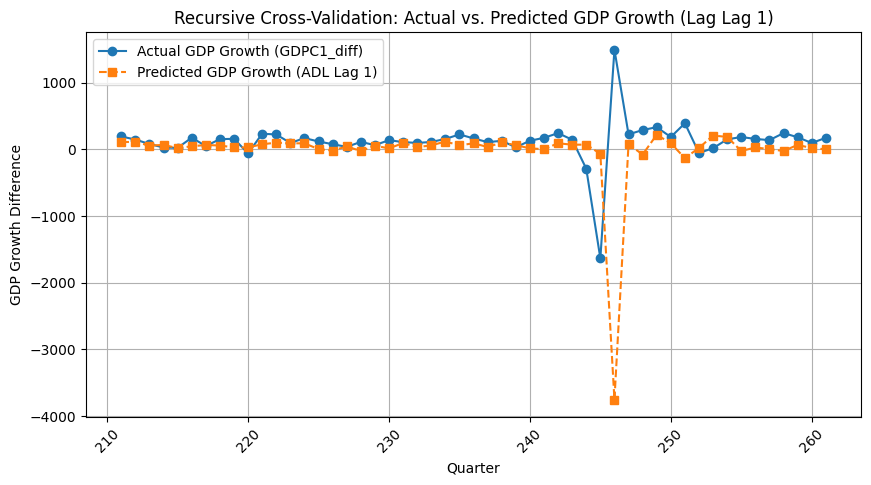

Recursive Cross-Validation RMSE for ADL Lag 1: 780.8870


In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Define the target variable (GDP growth difference)
y = quarterly_selected_data['GDPC1_diff']

# Define predictor variables for different lags
X_lag1 = quarterly_selected_data[[    'GDPCTPI_diff_lag1', 'INDPRO_diff_lag1', 'IPFINAL_diff_lag1', 'IPCONGD_diff_lag1',
    'IPMAT_diff_lag1', 'PAYEMS_diff_lag1', 'MANEMP_diff_lag1', 'LNS14000012_diff_lag1',
    'UEMPLT5_diff_lag1', 'PCECC96_pct_change_lag1', 'CMRMTSPLx_pct_change_lag1',
    'GS10_pct_change_lag1', 'TB3MS_pct_change_lag1']]


# Add constant terms for each lag model
X_lag1 = sm.add_constant(X_lag1)


# Define training size (80% of data)
initial_train_size = int(len(X_lag1) * 0.8)

# Initialize lists for storing RMSEs
rmse_results = {}

# Function to perform recursive cross-validation for a given lag model
def recursive_cross_validation(X, lag_name):
    actual_values = []
    predicted_values = []
    test_periods = []

    for i in range(initial_train_size, len(X) - 1):  # Exclude last row
        # Define training dataset
        X_train = X.iloc[:i]
        y_train = y.iloc[:i]

        # Define test set (next quarter)
        X_test = X.iloc[i].values.reshape(1, -1)
        y_test = y.iloc[i]

        # Fit ADL Model on training data
        adl_model = sm.OLS(y_train, X_train).fit()

        # Predict GDP change for next quarter
        y_pred = adl_model.predict(X_test)[0]

        # Store actual and predicted values
        actual_values.append(y_test)
        predicted_values.append(y_pred)
        test_periods.append(quarterly_selected_data.index[i])

    # Compute RMSE
    rmse = np.sqrt(mean_squared_error(actual_values, predicted_values))
    rmse_results[lag_name] = rmse

    # Plot Actual vs. Predicted GDP Growth Differences
    plt.figure(figsize=(10, 5))
    plt.plot(test_periods, actual_values, label="Actual GDP Growth (GDPC1_diff)", marker='o', linestyle='-')
    plt.plot(test_periods, predicted_values, label=f"Predicted GDP Growth (ADL {lag_name})", marker='s', linestyle='--')
    plt.xlabel("Quarter")
    plt.ylabel("GDP Growth Difference")
    plt.title(f"Recursive Cross-Validation: Actual vs. Predicted GDP Growth (Lag {lag_name})")
    plt.legend()
    plt.grid()
    plt.xticks(rotation=45)
    plt.show()

# Run cross-validation for different lag models
recursive_cross_validation(X_lag1, "Lag 1")

# Print RMSE results
for lag, rmse in rmse_results.items():
    print(f"Recursive Cross-Validation RMSE for ADL {lag}: {rmse:.4f}")
